In [1]:
!pip install spacy matplotlib seaborn pandas squarify --quiet



[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


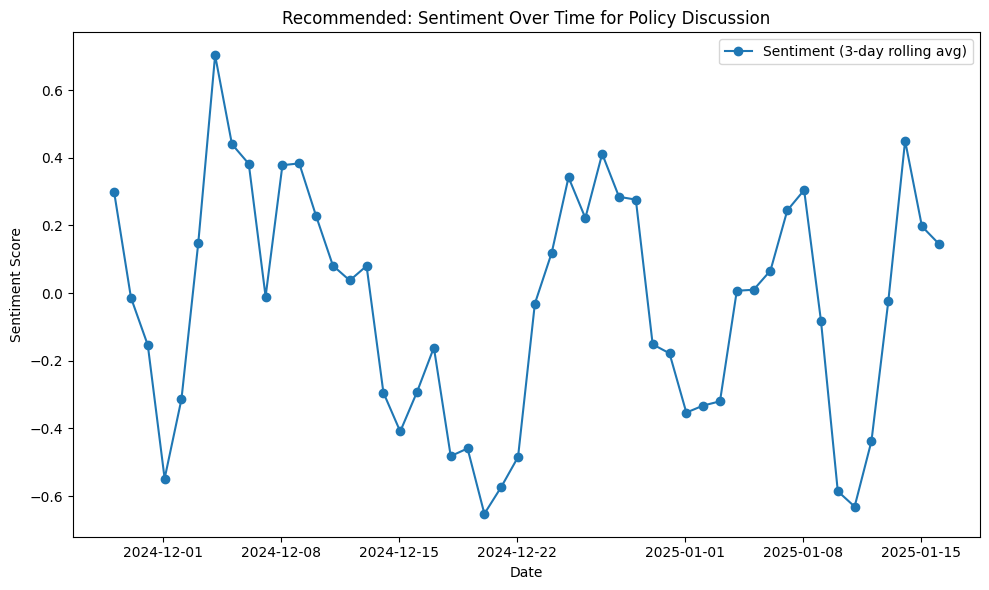

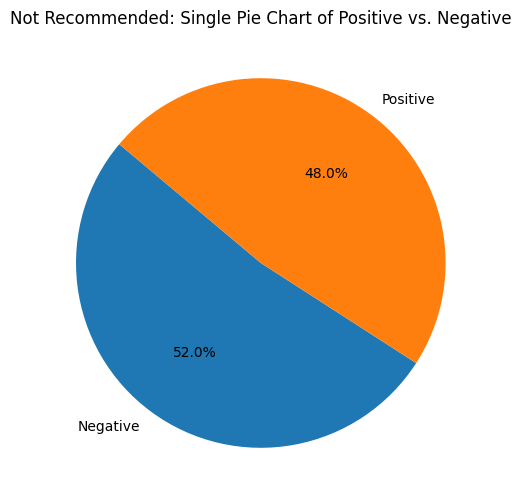

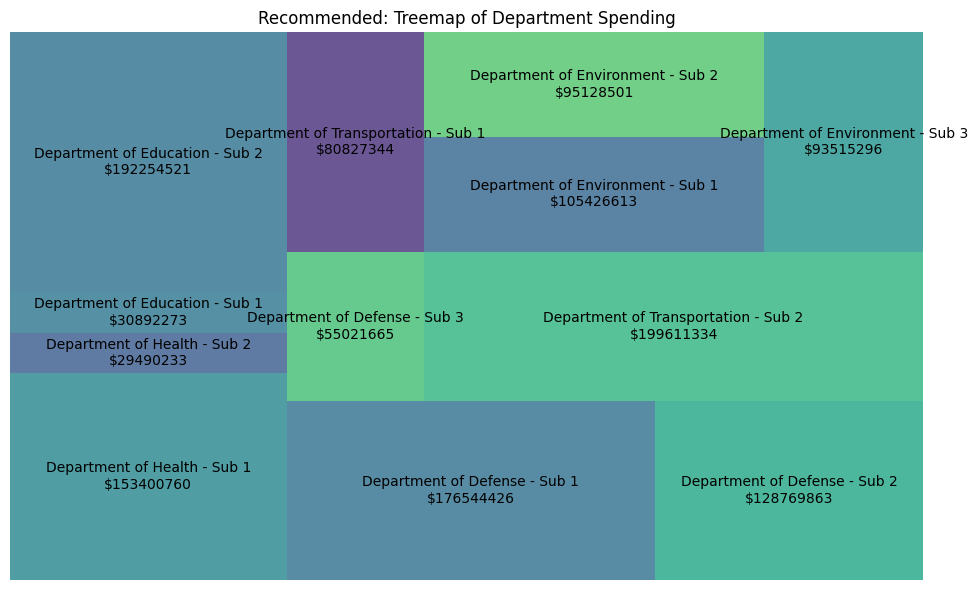

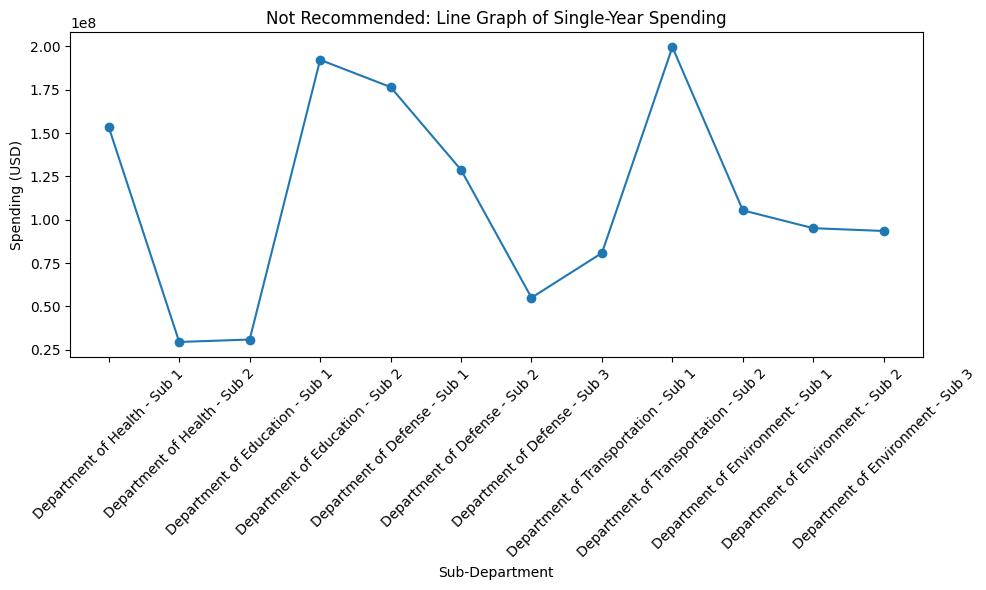

In [2]:
###############################################################################
# 1. SETUP: Imports and spaCy Model
###############################################################################
import spacy
import random
import string
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify  # For treemap
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Make sure you have downloaded a spaCy model, e.g.:
# python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

###############################################################################
# 2. SCENARIO A: SOCIAL MEDIA SENTIMENT ON A GOVERNMENT POLICY
###############################################################################
def generate_fake_social_media_data(num_posts=100):
    """
    Generate synthetic social media data about a hypothetical policy.
    Each item will include:
    - timestamp
    - username
    - text
    - sentiment (randomly assigned for demonstration)
    """
    fake_data = []
    
    start_date = datetime.now() - timedelta(days=num_posts)
    
    # Some sample “policy” keywords
    policy_keywords = [
        "HealthReform", "EducationBill", "InfrastructurePlan", 
        "DefenseSpending", "ClimateAct"
    ]
    # Some sample user names
    users = ["alice", "bob", "charlie", "diana", "edward", "felicia"]
    
    # Generate random posts
    for i in range(num_posts):
        # Random date
        post_date = start_date + timedelta(days=i)
        
        # Construct random text
        policy = random.choice(policy_keywords)
        # We'll just create a simple text with random words
        text = f"This is a post about {policy}. " \
               f"Government should do more. #Policy #Discussion"
        
        # Random sentiment in [-1, 1]
        sentiment = random.uniform(-1, 1)
        
        # Pick a random user
        user = random.choice(users)
        
        fake_data.append({
            "timestamp": post_date,
            "username": user,
            "text": text,
            "sentiment": sentiment
        })
    
    return pd.DataFrame(fake_data)

# Generate data
social_df = generate_fake_social_media_data(num_posts=50)

# Minimal spaCy processing: tokenization & NER
docs = [nlp(text) for text in social_df["text"]]
named_entities = []
for i, doc in enumerate(docs):
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    named_entities.append(entities)
    
social_df["named_entities"] = named_entities

###############################################################################
# 2A. RECOMMENDED VISUALIZATION FOR SCENARIO A:
#     LINE CHART SHOWING SENTIMENT OVER TIME
###############################################################################
plt.figure(figsize=(10, 6))
# Sort by timestamp
social_df_sorted = social_df.sort_values("timestamp")
# Rolling average to smooth out fluctuations (optional)
social_df_sorted["rolling_sentiment"] = (
    social_df_sorted["sentiment"].rolling(window=3, min_periods=1).mean()
)

plt.plot(
    social_df_sorted["timestamp"],
    social_df_sorted["rolling_sentiment"],
    marker="o",
    linestyle="-",
    label="Sentiment (3-day rolling avg)"
)
plt.title("Recommended: Sentiment Over Time for Policy Discussion")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()
plt.tight_layout()
plt.show()

###############################################################################
# 2B. NOT RECOMMENDED VISUALIZATION FOR SCENARIO A:
#     PIE CHART OF TOTAL POSITIVE VS. NEGATIVE
###############################################################################
# We'll just do a simple classification: sentiment >= 0 => Positive, <0 => Negative
social_df["sentiment_class"] = ["Positive" if s >= 0 else "Negative" 
                                for s in social_df["sentiment"]]
counts = social_df["sentiment_class"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Not Recommended: Single Pie Chart of Positive vs. Negative")
plt.show()

###############################################################################
# 3. SCENARIO B: GOVERNMENT SPENDING DATA
###############################################################################
def generate_fake_spending_data(num_departments=5):
    """
    Generate synthetic government spending data for multiple departments.
    Each item will include:
    - department name
    - spending amount
    - possible sub-departments
    """
    departments = [
        "Department of Health", 
        "Department of Education",
        "Department of Defense",
        "Department of Transportation",
        "Department of Environment",
    ]
    
    if num_departments < len(departments):
        departments = departments[:num_departments]
    
    data = []
    for dept in departments:
        # Create 1-3 sub-departments
        num_subs = random.randint(1, 3)
        for sub_id in range(num_subs):
            sub_name = f"{dept} - Sub {sub_id+1}"
            spending = random.randint(10_000_000, 200_000_000)  # random $10M-$200M
            data.append({"department": dept, 
                         "sub_department": sub_name, 
                         "spending": spending})
    return pd.DataFrame(data)

spending_df = generate_fake_spending_data(num_departments=5)

# Minimal spaCy usage: just pretend we parse department names from text
spending_texts = [
    f"The {row.department} (Specifically {row.sub_department}) spent ${row.spending}"
    for _, row in spending_df.iterrows()
]
spending_docs = [nlp(text) for text in spending_texts]
dept_entities = []
for doc in spending_docs:
    # We might get ORG or GPE, depending on spaCy's guess
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    dept_entities.append(entities)
spending_df["extracted_entities"] = dept_entities

###############################################################################
# 3A. RECOMMENDED VISUALIZATION FOR SCENARIO B:
#     TREEMAP (PART-TO-WHOLE SPENDING)
###############################################################################
# Summarize each sub-department's spending
# We'll just plot sub_department vs. spending in a treemap

plt.figure(figsize=(10, 6))
# Squarify expects a list of sizes and optionally labels
sizes = spending_df["spending"].tolist()
labels = spending_df["sub_department"] + "\n$" + spending_df["spending"].astype(str)

squarify.plot(
    sizes=sizes, 
    label=labels, 
    alpha=0.8
)
plt.title("Recommended: Treemap of Department Spending")
plt.axis("off")
plt.tight_layout()
plt.show()

###############################################################################
# 3B. NOT RECOMMENDED VISUALIZATION FOR SCENARIO B:
#     LINE GRAPH OF SPENDING (SINGLE SNAPSHOT)
###############################################################################
# A line graph is not very meaningful for a single snapshot of spending
plt.figure(figsize=(10, 6))
plt.plot(spending_df["sub_department"], spending_df["spending"], marker="o")
plt.title("Not Recommended: Line Graph of Single-Year Spending")
plt.xlabel("Sub-Department")
plt.ylabel("Spending (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Freedom of Information Act (FOIA) Request Summaries
Data Description

Text: Summaries of FOIA requests, describing the type of information sought and the agencies involved.
Possible Sources: Synthetic text describing requests or actual FOIA reading room summaries.
Best Visualization: Customized SpaCy “Displacy” Visual with Additional Metadata

Why?
FOIA requests often involve agencies, requesters, topics, and justifications.
A custom displacy HTML rendering can highlight not only named entities but also add overlays for each entity indicating request status (“pending,” “completed,” “denied”), possibly with color-coded labels.
This gives immediate insight into what is being requested and from whom, as well as the status of each request, in a single view.
Less Effective Visualization: Bar Chart of Request Counts by Agency

Why Not?
Although it can show which agencies are requested most often, it loses granularity (e.g., why requests are made, which specific topics are requested).
FOIA text is often about the detailed context, and an aggregated bar chart won’t show that detail.

In [3]:
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")

text = """
Request #1234: John Doe requests documents regarding environmental impact reports 
from the Environmental Protection Agency. Status: Pending

Request #5678: Jane Smith requests communications about budget allocation 
from the Department of Defense. Status: Denied
"""

doc = nlp(text)

# Custom rendering with metadata
colors = {"ORG": "linear-gradient(90deg, #aa9cfc, #fc9ce7)"}

options = {
    "ents": ["PERSON", "ORG"],
    "colors": colors
}

html = displacy.render(doc, style='ent', options=options, jupyter=False)
# Post-process or embed status info in the HTML (e.g., adding badges after each recognized entity)
# For a real example, you'd parse out "Status: X" as additional data and conditionally color-code it.

# Display in a Jupyter Notebook environment or write to an HTML file.
with open("foia_requests.html", "w") as f:
    f.write(html)

# 2. Public Health Bulletins and Outbreak Updates
Data Description

Text: Government public health announcements, disease outbreak reports, vaccine updates.
Possible Sources: CDC bulletins, WHO situation reports, local government health department updates.
Best Visualization: Temporal Entity Timeline

Why?
Outbreak communications often revolve around when certain events happen (detection of the first case, new variant discovered, vaccination drive launch).
Extracting time expressions, named entities (diseases, locations, organizations), and then plotting them on a timeline (e.g., Plotly timeline charts) helps visualize the chronological evolution of an outbreak.
Less Effective Visualization: Plain Dependency Parse

Why Not?
While dependency parses are useful for sentence structure, they don’t inherently convey temporal trends across multiple documents.
Focusing solely on dependency trees for each announcement might overwhelm and distract from the critical timeline perspective.

In [4]:
import spacy
from spacy import displacy
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load spaCy model
nlp = spacy.load("en_core_web_sm")

# 2. Sample text (cyber threat intelligence)
text = """
APT28 group exploited CVE-2024-1234 in Microsoft Exchange, 
gaining unauthorized access to classified documents. 
They subsequently deployed a payload that exfiltrated data to a remote server.
"""

doc = nlp(text)

# 3. Visualize dependencies using displacy
displacy.render(doc, style='dep', jupyter=True)

# 4. Build a simple Named Entity Graph
entities = [(ent.text, ent.label_) for ent in doc.ents]

# Create a graph and add nodes for each entity
G = nx.Graph()
for ent_text, ent_label in entities:
    G.add_node(ent_text, label=ent_label)

# Example of adding edges (naive approach: connect consecutive entities)
for i in range(len(entities)-1):
    G.add_edge(entities[i][0], entities[i+1][0])

# 5. Draw the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue')
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels)
plt.show()


ModuleNotFoundError: No module named 'networkx'